---
title: "Python 基础入门(3)"
description: "本内容面向的读者是没有编程经验的纯编程小白，可以帮助你学习 Python 基础"
date: 2026-08-31

categories:
  - Python
  - Code
---

## 函数

上一篇我们学了 Python 的基础语法，所有代码都是从上往下顺序执行的。但真实的程序不可能把所有逻辑都写成流水线，我们需要把代码拆分成一个个函数，每个函数负责一件事，需要的时候调用就行。

这篇除了函数本身，还会讲 Python 中非常实用的 lambda 表达式、列表推导式、字典推导式等语法糖。这些东西第一次见可能觉得有点花哨，但用熟了你就会发现它们能大幅简化代码，刷算法题的时候尤其好用。

### 函数定义与调用

函数就是一段可以重复调用的代码块，给它一个名字，需要的时候调用就行。

Python 用 `def` 关键字定义函数：

```{pyodide}
#| caption: "函数定义与调用"
# 定义一个函数：计算两个数的和
# def 是关键字，add 是函数名，a 和 b 是参数
def add(a, b):
    return a + b

# 没有返回值的函数，不需要写 return（或者写 return None）
def greet(name):
    print("你好，" + name + "！")

# 调用函数
result = add(3, 5)
# 输出：8
print(result)

# 输出：你好，Python！
greet("Python")

# 函数的返回值可以直接参与运算
# 输出：19
print(add(10, 9))
```

注意 Python 不需要声明参数类型和返回值类型——因为 Python 是动态类型语言，变量的类型在运行时自动确定。你传什么进去，它就是什么类型。

还有一点，Python 是用**缩进**来划分代码块的。`def` 下面缩进的部分就是函数体，缩进结束函数就结束了。一般用 4 个空格缩进。

### 参数

#### 默认参数

定义函数时可以给参数设置默认值，调用时如果不传这个参数，就用默认值：

```{pyodide}
#| caption: "默认参数"
# b 有默认值 1，调用时可以不传
def power(a, b=2):
    return a ** b

# 只传一个参数，b 使用默认值 2
# 输出：9（即 3 的 2 次方）
print(power(3))

# 传两个参数，b = 3
# 输出：27（即 3 的 3 次方）
print(power(3, 3))

# 也可以用参数名指定，这叫"关键字参数"
# 输出：16（即 2 的 4 次方）
print(power(a=2, b=4))
```

默认参数有个规则：**有默认值的参数必须放在没有默认值的参数后面**。你想想就知道了，如果放前面，Python 就分不清你传的值是给谁的。

#### 可变参数 *args 和 **kwargs

有时候你不确定函数会接收多少个参数，Python 提供了两种方式来处理：

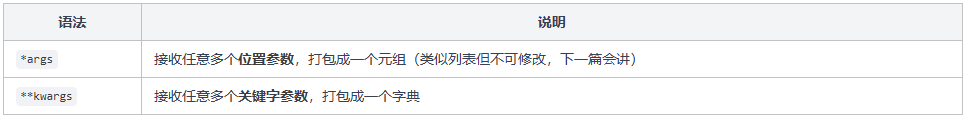

```{pyodide}
#| caption: "可变参数 *args"
# *args 把多余的位置参数打包成元组
def my_sum(*args):
    print("收到的参数：", args)
    total = 0
    for num in args:
        total += num
    return total

# 可以传任意多个参数
# 输出：收到的参数： (1, 2, 3)
# 输出：6
print(my_sum(1, 2, 3))

# 输出：收到的参数： (10, 20, 30, 40)
# 输出：100
print(my_sum(10, 20, 30, 40))
```

```{pyodide}
#| caption: "可变参数**kwargs"
# **kwargs 把多余的关键字参数打包成字典
def print_info(**kwargs):
    print("收到的参数：", kwargs)
    for key, value in kwargs.items():
        print(f"  {key} = {value}")

# 用关键字参数调用
# 输出：
# 收到的参数： {'name': 'Alice', 'age': 25, 'city': '北京'}
#   name = Alice
#   age = 25
#   city = 北京
print_info(name="Alice", age=25, city="北京")
```

`*args` 和 `**kwargs` 只是约定俗成的名字，你也可以叫 `*numbers` 或 `**options`，关键是前面的 `*` 和 `**`。

说实话，你自己写代码的时候用到 `*args` 和 `**kwargs` 的场景不会太多。但看别人的代码时经常会遇到，所以要认识它们。

#### 多返回值

Python 的函数可以返回多个值，本质上是返回一个元组，然后用**拆包**的方式接收：

```{pyodide}
#| caption: "多返回值"
# 返回商和余数
def divide(a, b):
    return a // b, a % b

# 用两个变量接收两个返回值（元组拆包）
q, r = divide(10, 3)
# 输出：商 = 3, 余数 = 1
print(f"商 = {q}, 余数 = {r}")

# 其实返回的是一个元组
result = divide(10, 3)
# 输出：(3, 1)
print(result)

# 如果只需要其中一个值，用 _ 占位
_, remainder = divide(17, 5)
# 输出：余数 = 2
print(f"余数 = {remainder}")
```

`_` 是一个约定俗成的"我不需要这个值"的写法，Python 不会报错，但实际上 `_` 也是一个合法变量名，只是我们用它来表示"这个值我不关心"。

多返回值在刷算法题时很实用，比如一个函数既要返回最大值，又要返回最大值的下标，用多返回值就很方便。

### lambda 表达式

lambda 是一种创建匿名函数的简洁写法，适合写那些只用一次的简单函数。

语法：`lambda 参数: 表达式`

```{pyodide}
#| caption: "lambda 基础"
# 普通函数写法
def add(a, b):
    return a + b

# 等价的 lambda 写法
add2 = lambda a, b: a + b

# 两者效果一样
# 输出：8
print(add(3, 5))
# 输出：8
print(add2(3, 5))

# lambda 只能写一个表达式，不能写多行语句
# 常用于简单的运算
square = lambda x: x ** 2
# 输出：25
print(square(5))
```

你可能会想：这跟普通函数有啥区别？单独用确实没什么区别。`lambda` 真正的用武之地是**作为参数传递给其他函数**，最经典的就是排序：

```{pyodide}
#| caption: "lambda 配合 sorted 排序"

# 一组学生，每个人是 (姓名, 成绩) 的元组
students = [("Alice", 88), ("Bob", 95), ("Charlie", 72), ("Diana", 91)]

# 按成绩从高到低排序
# key 参数告诉 sorted 用什么规则排序
# lambda x: x[1] 表示取每个元组的第二个元素（成绩）
ranked = sorted(students, key=lambda x: x[1], reverse=True)
# 输出：[('Bob', 95), ('Diana', 91), ('Alice', 88), ('Charlie', 72)]
print(ranked)

# 按姓名长度排序
by_name_len = sorted(students, key=lambda x: len(x[0]))
# 输出：[('Bob', 95), ('Alice', 88), ('Diana', 91), ('Charlie', 72)]
print(by_name_len)

# 对普通列表也行：按绝对值排序
nums = [-3, 1, -4, 1, 5, -9, 2, -6]
sorted_nums = sorted(nums, key=lambda x: abs(x))
# 输出：[1, 1, 2, -3, -4, 5, -6, -9]
print(sorted_nums)
```

`sorted` 函数的 `key` 参数接收一个函数，这个函数告诉 `sorted` "用什么规则来比较元素"。用 `lambda` 写一行就搞定，非常简洁。

如果不用 `lambda`，你就得单独定义一个函数然后传进去，多写好几行。刷算法题时 `sorted + lambda` 的组合用得非常频繁，一定要熟练掌握。

### 列表推导式

列表推导式（List Comprehension）是 Python 中非常有特色的语法，能用一行代码生成一个列表。看完你就知道为什么大家都说 Python 代码简洁了。

#### 基本语法

```{pyodide}
#| caption: "列表推导式基础"
# 传统写法：生成 0~9 每个数的平方
squares = []
for x in range(10):
    squares.append(x ** 2)
# 输出：[0, 1, 4, 9, 16, 25, 36, 49, 64, 81]
print(squares)

# 列表推导式写法：一行搞定
squares2 = [x ** 2 for x in range(10)]
# 输出：[0, 1, 4, 9, 16, 25, 36, 49, 64, 81]
print(squares2)

# 再看几个例子
# 每个元素乘以 2
doubled = [x * 2 for x in range(5)]
# 输出：[0, 2, 4, 6, 8]
print(doubled)

# 生成字符串列表
names = ["alice", "bob", "charlie"]
upper_names = [name.upper() for name in names]
# 输出：['ALICE', 'BOB', 'CHARLIE']
print(upper_names)
```

语法模板：`[表达式 for 变量 in 可迭代对象]`

意思是：遍历可迭代对象，对每个元素执行表达式，把结果收集成一个新列表。本质上就是 for 循环 + append 的简写。

#### 带条件过滤

列表推导式还可以加上 `if` 条件，只保留满足条件的元素：

```{pyodide}
#| caption: "带条件过滤的列表推导式"
# 只保留偶数
evens = [x for x in range(10) if x % 2 == 0]
# 输出：[0, 2, 4, 6, 8]
print(evens)

# 只保留正数
nums = [-3, 1, -4, 1, 5, -9, 2, -6]
positives = [x for x in nums if x > 0]
# 输出：[1, 1, 5, 2]
print(positives)

# 过滤 + 变换可以同时做
# 只取偶数，然后算平方
even_squares = [x ** 2 for x in range(10) if x % 2 == 0]
# 输出：[0, 4, 16, 36, 64]
print(even_squares)

# 从字符串列表中筛选长度大于 3 的，并转为大写
words = ["hi", "hello", "hey", "world", "ok"]
long_words = [w.upper() for w in words if len(w) > 3]
# 输出：['HELLO', 'WORLD']
print(long_words)
```

语法模板：`[表达式 for 变量 in 可迭代对象 if 条件]`

先过滤（`if`），再变换（表达式），最后收集成列表。一行代码干了三件事，很爽吧？

#### 嵌套推导式

列表推导式可以嵌套，最常见的用途是创建二维列表：

```{pyodide}
#| caption: "嵌套推导式"
# 创建 3 行 4 列的二维列表，初始值都是 0
# 外层循环 3 次（行），内层循环 4 次（列）
matrix = [[0 for j in range(4)] for i in range(3)]
# 输出：[[0, 0, 0, 0], [0, 0, 0, 0], [0, 0, 0, 0]]
print(matrix)

# 修改某个元素验证一下
matrix[1][2] = 99
# 输出：[[0, 0, 0, 0], [0, 0, 99, 0], [0, 0, 0, 0]]
print(matrix)

# 创建乘法表（前 5 行）
table = [[i * j for j in range(1, 6)] for i in range(1, 6)]
for row in table:
    print(row)
# 输出：
# [1, 2, 3, 4, 5]
# [2, 4, 6, 8, 10]
# [3, 6, 9, 12, 15]
# [4, 8, 12, 16, 20]
# [5, 10, 15, 20, 25]
```

这里要特别注意一个坑：创建二维列表不能用 `[[0]*4]*3` 这种写法。因为 `*3` 复制的是引用，三行指向的是同一个列表对象，修改一行其他行也会变。用列表推导式 `[[0 for j in range(4)] for i in range(3)]` 才是正确的做法，每行都是独立的列表。

这个坑在刷算法题时非常容易踩，一定要记住。

### 字典推导式 / 集合推导式

既然列表有推导式，字典和集合自然也有。语法几乎一样，只是把 [] 换成 {}。

```{pyodide}
#| caption: "字典推导式 / 集合推导式"
# 字典推导式：{key: value for 变量 in 可迭代对象}
# 生成 1~5 的平方字典
squares_dict = {x: x ** 2 for x in range(1, 6)}
# 输出：{1: 1, 2: 4, 3: 9, 4: 16, 5: 25}
print(squares_dict)

# 从两个列表生成字典
keys = ["name", "age", "city"]
values = ["Alice", 25, "北京"]
info = {k: v for k, v in zip(keys, values)}
# 输出：{'name': 'Alice', 'age': 25, 'city': '北京'}
print(info)

# 字典推导式也可以带条件过滤
# 只保留值大于 3 的
filtered = {k: v for k, v in squares_dict.items() if v > 3}
# 输出：{2: 4, 3: 9, 4: 16, 5: 25}
print(filtered)

# 集合推导式：{表达式 for 变量 in 可迭代对象}
# 注意集合会自动去重
nums = [1, 2, 2, 3, 3, 3, 4, 4, 4, 4]
unique_squares = {x ** 2 for x in nums}
# 输出：{16, 1, 4, 9}（集合无序）
print(unique_squares)
```

字典推导式用 `{k: v for ...}`，有冒号；集合推导式用 `{x for ...}`，没冒号。区别就在这。

另外代码中用到的 `zip` 函数很实用，它能把两个列表"拉链式"配对，后面刷题经常用到。

### 小结

这篇讲了 Python 函数和几种实用的语法糖：

**函数**让你把代码拆成可复用的小块，`def` 定义，调用时传参就行。`lambda` 是匿名函数的简写，配合 `sorted` 排序非常方便。列表推导式让你一行代码生成一个列表，加上 `if` 还能过滤。字典推导式和集合推导式同理。

关键点回顾：

- 默认参数必须放在普通参数后面，`*args` 接收位置参数，`**kwargs` 接收关键字参数
- 多返回值本质是元组拆包，用 `a, b = func()` 接收
- `sorted(list, key=lambda x: ...)` 是最常用的自定义排序方式
- 列表推导式 `[表达式 for x in 可迭代 if 条件]` 能大幅简化代码
- 创建二维列表用推导式 `[[0]*n for _ in range(m)]`，不要用 `[[0]*n]*m`
下一篇我们来学 Python 的常用数据结构，包括 `list`、`tuple`、`string`、`dict`、`set`，以及刷题常用的 `deque` 和 `heapq`。